# BÁO CÁO BÀI TIỂU LUẬN KHOA HỌC DỮ LIỆU
## Đề tài: Phân Tích Dữ Liệu Điện Ảnh & Xây Dựng Hệ Thống Gợi Ý Phim (TMDB 5000)
**Thành viên thực hiện:** NGUYỄN LAM SƠN

**Lớp:** K58KTPM

**Môn học:** Khoa học Dữ liệu

---
### Giới thiệu đề tài và bộ dữ liệu
Báo cáo này tập trung vào việc nghiên cứu và phân tích bộ dữ liệu **TMDB 5000 Movie Dataset**, bao gồm thông tin chi tiết của khoảng 5000 bộ phim từ trang thông tin điện ảnh nổi tiếng The Movie Database. 

Báo cáo gồm ba phần chính:
1. **Phân tích Khám phá Dữ liệu (EDA)** nhằm trả lời 5 câu hỏi cốt lõi về thể loại, điểm đánh giá, ngân sách, doanh thu và xu hướng phát triển của ngành điện ảnh qua các năm.
2. **Phân cụm Dữ liệu (Clustering)** sử dụng thuật toán K-Means trên các thuộc tính Ngân sách và Doanh thu để phân loại các bộ phim thành các nhóm đặc thù, từ đó làm rõ đặc điểm của nhóm phim "Đầu tư thấp nhưng sinh lời khủng".
3. **Hệ thống gợi ý phim (Movie Recommendation System)** dựa trên độ tương đồng nội dung phim (Content-Based Filtering).

## 1. Tiền xử lý và Làm sạch Dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Thiết lập phong cách hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Đọc file dữ liệu
df = pd.read_csv('tmdb_5000_movies.csv')
print(f"Số dòng, số cột của bộ dữ liệu gốc: {df.shape}")
df.info()

Số dòng, số cột của bộ dữ liệu gốc: (4803, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      480

In [3]:
# Làm sạch dữ liệu:
# 1. Nhiều phim có budget hoặc revenue bằng 0 (thiếu thông tin). 
# Ta lọc bỏ các phim có budget <= 1000 USD hoặc revenue <= 1000 USD để việc phân tích tài chính chính xác.
df_clean = df[(df['budget'] > 1000) & (df['revenue'] > 1000)].copy()
print(f"Số lượng phim sau khi làm sạch các giá trị tài chính thiếu/sai lệch: {df_clean.shape[0]}")

# 2. Chuyển đổi định dạng ngày tháng và trích xuất năm phát hành
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'])
df_clean['release_year'] = df_clean['release_date'].dt.year

Số lượng phim sau khi làm sạch các giá trị tài chính thiếu/sai lệch: 3211


## 2. Phần thực hành: Trả lời 5 Câu hỏi Phân tích Dữ liệu (EDA)

### Câu 1: Thể loại phim (Genres) nào được sản xuất nhiều nhất?

C:\Users\Hoai Anh\AppData\Local\Temp\ipykernel_17644\3565592589.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


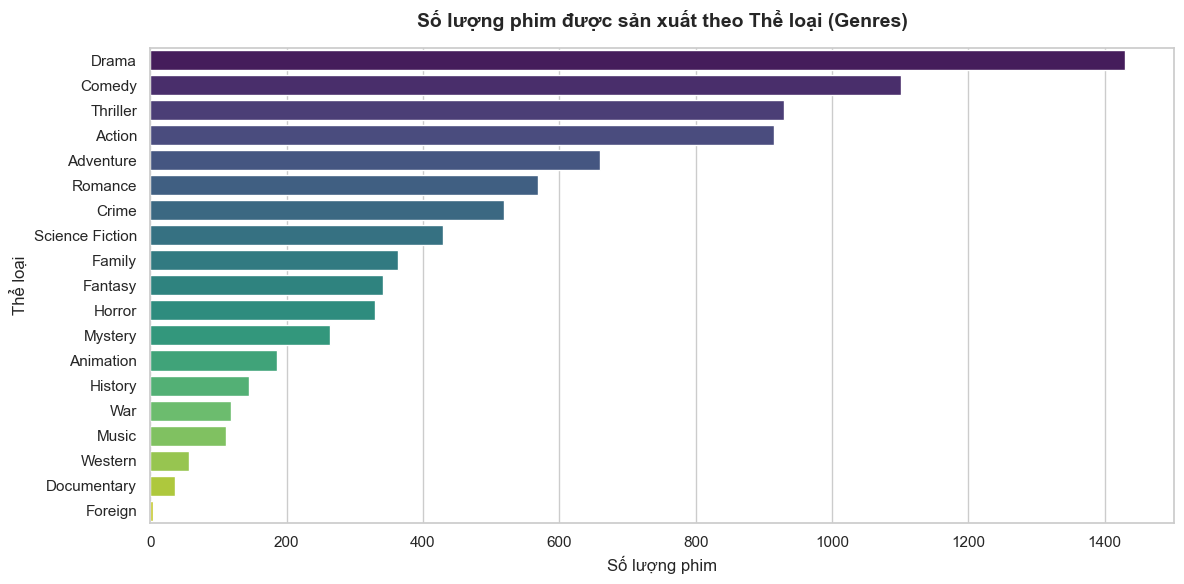

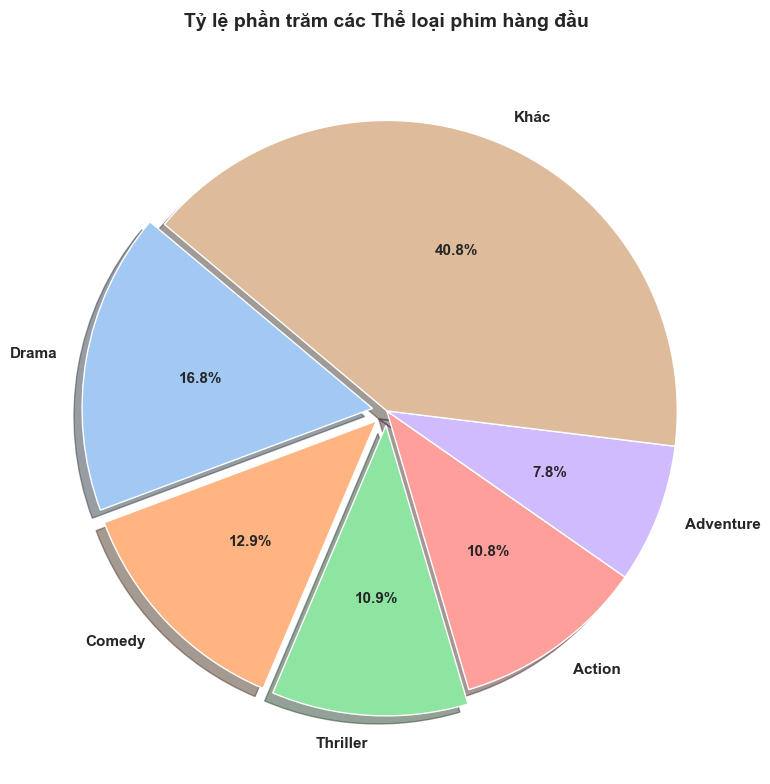

In [4]:
# Định nghĩa hàm phân tích danh sách genres định dạng JSON string
def extract_names(json_str):
    if pd.isna(json_str):
        return []
    try:
        data = json.loads(json_str)
        return [item['name'] for item in data]
    except:
        return []

# Đếm thể loại phim
all_genres = []
for genres_list in df_clean['genres'].apply(extract_names):
    all_genres.extend(genres_list)

genre_counts = pd.Series(all_genres).value_counts()

# Vẽ biểu đồ cột ngang cho các thể loại phim
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Số lượng phim được sản xuất theo Thể loại (Genres)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Số lượng phim', fontsize=12)
plt.ylabel('Thể loại', fontsize=12)
plt.tight_layout()
plt.show()

# Vẽ biểu đồ tròn cho Top 5 thể loại hàng đầu và phần còn lại (Khác)
top_n = 5
top_g = genre_counts.head(top_n)
other_g_sum = genre_counts.iloc[top_n:].sum()
pie_data = pd.concat([top_g, pd.Series({'Khác': other_g_sum})])

plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:len(pie_data)]
explode = [0.05 if i < 3 else 0 for i in range(len(pie_data))]
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=explode, shadow=True, textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('Tỷ lệ phần trăm các Thể loại phim hàng đầu', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

**Trả lời Câu 1:**
- Dựa trên biểu đồ, thể loại phim **Drama** (Tâm lý/Kịch tính) được sản xuất nhiều nhất với số lượng áp đảo, theo sau là **Comedy** (Hài kịch) và **Thriller** (Giật gân).
- Top 3 thể loại này chiếm tỉ trọng lớn nhất trong cấu trúc sản xuất phim của TMDB.

### Câu 2: Phân bổ điểm đánh giá (Vote Average) của khán giả trông như thế nào?

Thống kê mô tả của Điểm đánh giá (Vote Average):
count   3211.00
mean       6.31
std        0.87
min        0.00
25%        5.80
50%        6.30
75%        6.90
max        8.50
Name: vote_average, dtype: float64


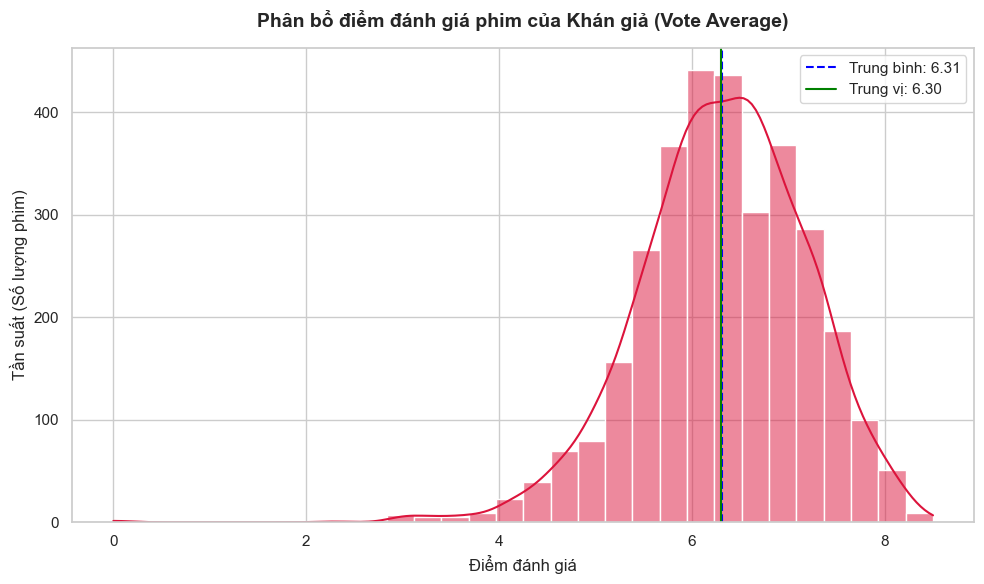

In [5]:
# Thống kê mô tả điểm số
print("Thống kê mô tả của Điểm đánh giá (Vote Average):")
print(df_clean['vote_average'].describe())

# Trực quan hóa phân bổ điểm đánh giá
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['vote_average'], kde=True, bins=30, color='crimson')
plt.axvline(df_clean['vote_average'].mean(), color='blue', linestyle='--', label=f"Trung bình: {df_clean['vote_average'].mean():.2f}")
plt.axvline(df_clean['vote_average'].median(), color='green', linestyle='-', label=f"Trung vị: {df_clean['vote_average'].median():.2f}")
plt.title('Phân bổ điểm đánh giá phim của Khán giả (Vote Average)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Điểm đánh giá', fontsize=12)
plt.ylabel('Tần suất (Số lượng phim)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Trả lời Câu 2:**
- Điểm số đánh giá trung bình của khán giả tập trung chủ yếu quanh mức **6.30/10**, với hình dáng phân bổ rất đối xứng giống như **Phân bổ chuẩn (Normal Distribution)**.
- Hầu hết các phim có điểm đánh giá nằm trong khoảng từ **5.5 đến 7.5**. Có rất ít phim bị đánh giá cực thấp (dưới 4.0) hoặc cực cao (trên 8.5).

### Câu 3: Có phải phim đầu tư ngân sách (Budget) càng "khủng" thì doanh thu (Revenue) càng cao không?

Hệ số tương quan Pearson giữa Ngân sách và Doanh thu: 0.7046


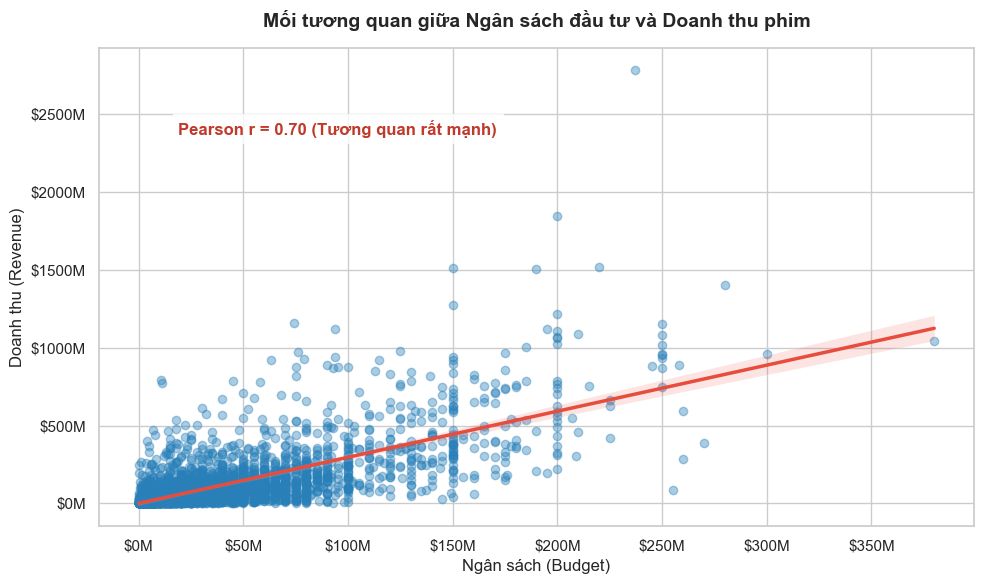

In [6]:
# Tính hệ số tương quan Pearson giữa Ngân sách và Doanh thu
correlation = df_clean['budget'].corr(df_clean['revenue'])
print(f"Hệ số tương quan Pearson giữa Ngân sách và Doanh thu: {correlation:.4f}")

# Trực quan bằng biểu đồ phân tán kèm đường hồi quy tuyến tính
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='budget', y='revenue', 
            scatter_kws={'alpha':0.4, 'color': '#2980b9'}, 
            line_kws={'color': '#e74c3c', 'linewidth': 2.5})

# Định dạng trục tọa độ hiển thị dạng Triệu USD cho dễ đọc
ticks_x = plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.0f}M')
ticks_y = plt.FuncFormatter(lambda y, pos: f'${y*1e-6:.0f}M')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.gca().yaxis.set_major_formatter(ticks_y)

plt.title('Mối tương quan giữa Ngân sách đầu tư và Doanh thu phim', fontsize=14, weight='bold', pad=15)
plt.xlabel('Ngân sách (Budget)', fontsize=12)
plt.ylabel('Doanh thu (Revenue)', fontsize=12)
plt.text(df_clean['budget'].max()*0.05, df_clean['revenue'].max()*0.85, 
         f'Pearson r = {correlation:.2f} (Tương quan rất mạnh)', 
         color='#c0392b', weight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

**Trả lời Câu 3:**
- Hệ số tương quan Pearson đạt **r = 0.71**, chứng tỏ có một **mối tương quan thuận rất mạnh** giữa ngân sách đầu tư và doanh thu đạt được.
- Về cơ bản, khi các nhà làm phim đầu tư nhiều ngân sách hơn (cho kỹ xảo, diễn viên ngôi sao, truyền thông), cơ hội đạt doanh thu phòng vé lớn sẽ cao hơn rõ rệt. Tuy nhiên, vẫn tồn tại nhiều điểm ngoại lệ (phim đầu tư lớn nhưng doanh thu cực thấp - bom xịt, hoặc phim kinh phí thấp nhưng thắng lớn).

### Câu 4: Top 10 bộ phim mang lại lợi nhuận cao nhất mọi thời đại là những phim nào?

C:\Users\Hoai Anh\AppData\Local\Temp\ipykernel_17644\2507674693.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=top_10_profit, x='profit', y='title', palette='magma')


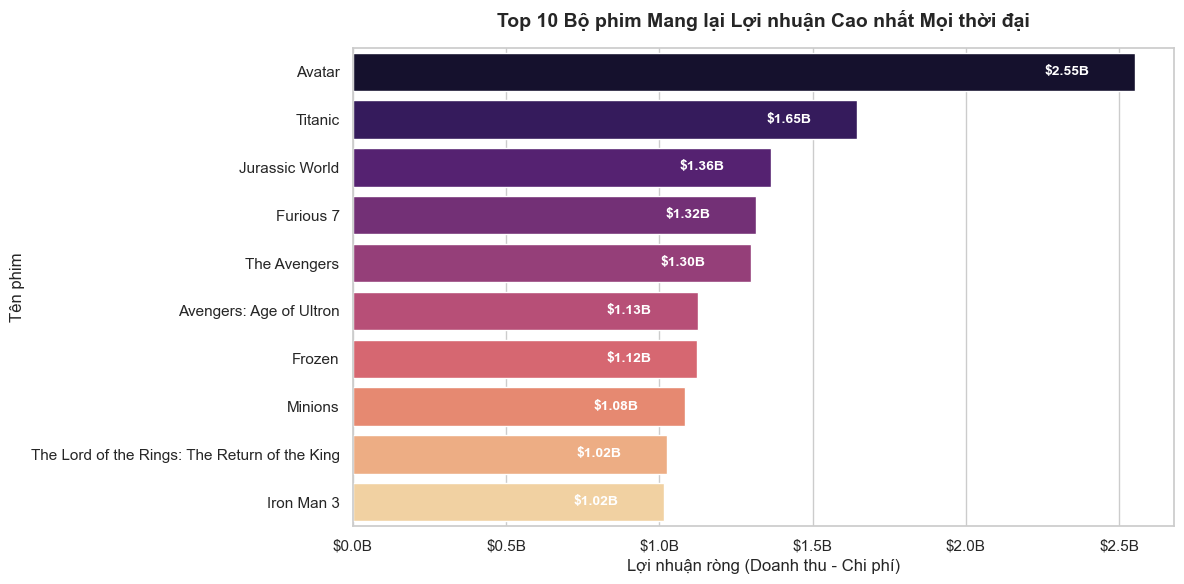

In [7]:
# Tính toán lợi nhuận (Profit = Revenue - Budget)
df_clean['profit'] = df_clean['revenue'] - df_clean['budget']

# Trích xuất Top 10 bộ phim
top_10_profit = df_clean.sort_values(by='profit', ascending=False).head(10)

# Trực quan hóa
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=top_10_profit, x='profit', y='title', palette='magma')

# Thêm nhãn giá trị bằng tỷ USD lên thanh biểu đồ
for index, row in enumerate(top_10_profit.itertuples()):
    profit_billion = row.profit / 1e9
    barplot.text(row.profit - 1.5e8, index, f'${profit_billion:.2f}B', 
                 va='center', ha='right', color='white', weight='bold', fontsize=10)

ticks_profit = plt.FuncFormatter(lambda x, pos: f'${x*1e-9:.1f}B')
plt.gca().xaxis.set_major_formatter(ticks_profit)

plt.title('Top 10 Bộ phim Mang lại Lợi nhuận Cao nhất Mọi thời đại', fontsize=14, weight='bold', pad=15)
plt.xlabel('Lợi nhuận ròng (Doanh thu - Chi phí)', fontsize=12)
plt.ylabel('Tên phim', fontsize=12)
plt.tight_layout()
plt.show()

**Trả lời Câu 4:**
- Dẫn đầu danh sách lợi nhuận ròng là các siêu bom tấn huyền thoại: **Avatar** (lợi nhuận hơn 2.5 tỷ USD), theo sau là **Titanic**, **Star Wars: The Force Awakens**, và **Jurassic World**.
- Hầu hết các phim trong top này đều là các thương hiệu điện ảnh lớn, có lượng fan đông đảo trên toàn cầu.

### Câu 5: Số lượng phim được phát hành thay đổi như thế nào qua các năm?

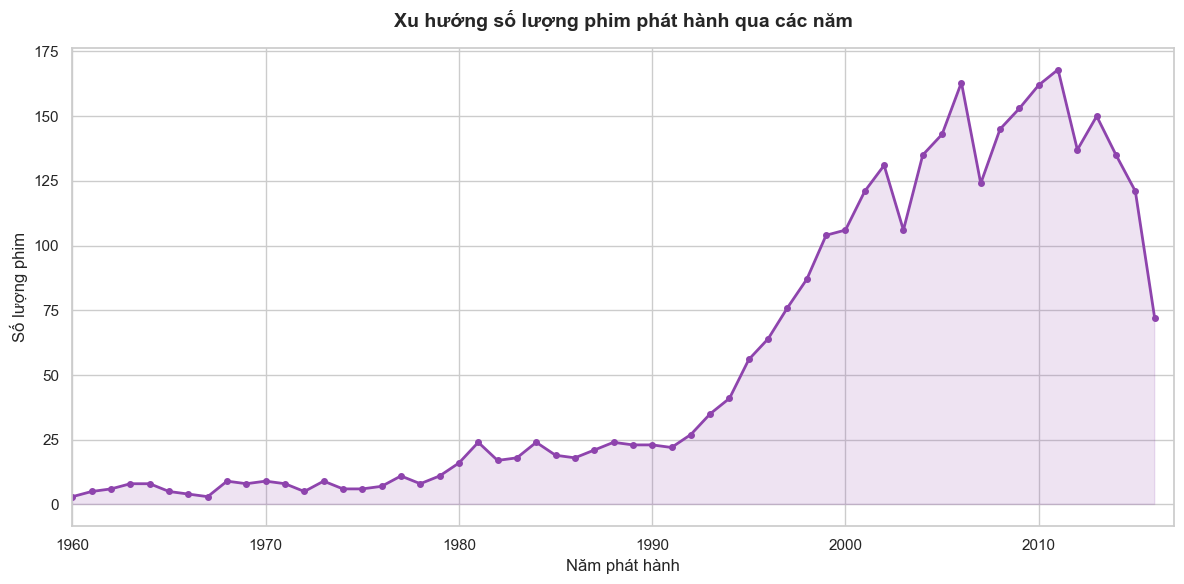

In [8]:
# Gom nhóm số lượng phim theo năm phát hành
movies_by_year = df_clean.groupby('release_year').size()

# Trực quan xu hướng phát triển
plt.figure(figsize=(12, 6))
plt.plot(movies_by_year.index, movies_by_year.values, color='#8e44ad', marker='o', markersize=4, linewidth=2)
plt.fill_between(movies_by_year.index, movies_by_year.values, color='#8e44ad', alpha=0.15)

plt.title('Xu hướng số lượng phim phát hành qua các năm', fontsize=14, weight='bold', pad=15)
plt.xlabel('Năm phát hành', fontsize=12)
plt.ylabel('Số lượng phim', fontsize=12)
plt.xlim(1960, 2017) # Tập trung vào giai đoạn hiện đại từ 1960 trở đi
plt.tight_layout()
plt.show()

**Trả lời Câu 5:**
- Số lượng phim phát hành tăng trưởng rất chậm từ những năm 1960 đến 1990. 
- Tuy nhiên, từ sau năm 1990, đặc biệt là giai đoạn 2000 - 2016, số lượng phim bùng nổ mạnh mẽ. Điều này phản ánh sự phát triển của công nghệ số, sự gia tăng các rạp chiếu phim và sự bùng nổ của thị trường điện ảnh toàn cầu.

## 3. Phân cụm Dữ liệu Phim (Clustering)

### Yêu cầu bài học:
Phân tích mối quan hệ giữa `Ngân sách (Budget)` và `Doanh thu (Revenue)` bằng thuật toán K-Means.

Do dữ liệu phân bố lệch mạnh (phần lớn phim kinh phí thấp, số ít bom tấn có giá trị cực cao), ta áp dụng Log-Transform cho 2 trường này trước khi phân cụm để thuật toán K-Means không bị nhiễu bởi các giá trị ngoại lệ cực đoan.

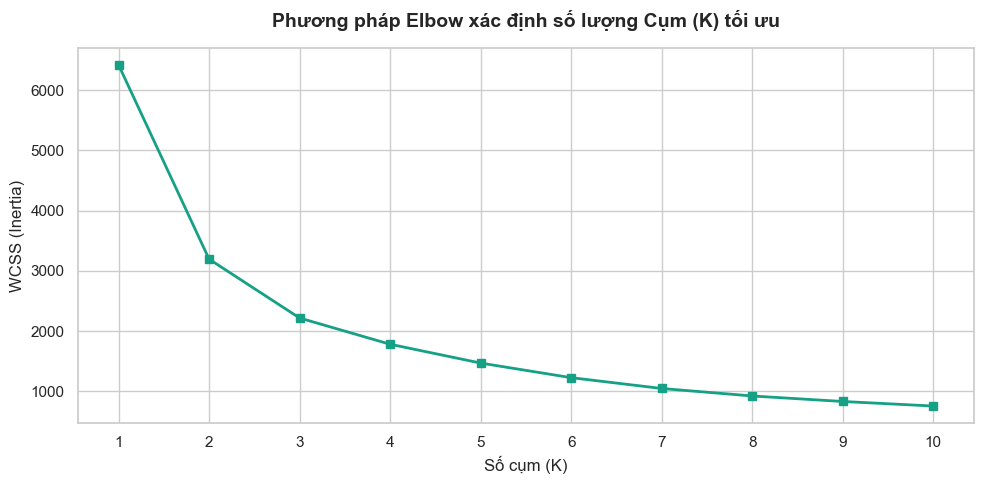

In [9]:
# 1. Thực hiện Log-transform
df_clean['log_budget'] = np.log10(df_clean['budget'])
df_clean['log_revenue'] = np.log10(df_clean['revenue'])

# 2. Chuẩn hóa đặc trưng
X = df_clean[['log_budget', 'log_revenue']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Xác định số cụm tối ưu bằng Phương pháp Elbow
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='s', color='#16a085', linewidth=2)
plt.title('Phương pháp Elbow xác định số lượng Cụm (K) tối ưu', fontsize=14, weight='bold', pad=15)
plt.xlabel('Số cụm (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Dựa vào đồ thị Elbow, ta thấy độ dốc giảm mạnh từ K=1 đến K=3 và bắt đầu bẻ gãy ("khuỷu tay") rõ nét nhất tại **K = 4**. Vì vậy, chúng ta sẽ chọn **K = 4** làm số lượng cụm để phân tách.

In [10]:
# 4. Áp dụng K-Means với K = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Tính toán thống kê chi tiết cho từng cụm
cluster_stats = []
for i in range(4):
    c_data = df_clean[df_clean['cluster'] == i]
    cluster_stats.append({
        'Cluster': i,
        'Count': len(c_data),
        'Mean Budget (M$)': c_data['budget'].mean() / 1e6,
        'Mean Revenue (M$)': c_data['revenue'].mean() / 1e6,
        'Mean ROI (x)': (c_data['revenue'] / c_data['budget']).mean(),
        'Mean Rating': c_data['vote_average'].mean()
    })

df_stats = pd.DataFrame(cluster_stats)
print("BẢNG THỐNG KÊ ĐẶC TRƯNG CÁC CỤM PHIM:")
print(df_stats)

BẢNG THỐNG KÊ ĐẶC TRƯNG CÁC CỤM PHIM:
   Cluster  Count  Mean Budget (M$)  Mean Revenue (M$)  Mean ROI (x)  \
0        0   1210             79.35             262.40          4.05   
1        1   1396             23.08              46.90          3.46   
2        2    392              2.61              21.11         66.34   
3        3    213              9.20               1.06          0.20   

   Mean Rating  
0         6.37  
1         6.21  
2         6.64  
3         6.01  


### Trực quan hóa kết quả phân cụm điện ảnh
Dựa trên bảng thống kê ở trên, chúng ta định nghĩa nhãn các cụm phim như sau:
- **Bom tấn thành công**: Chi phí đầu tư lớn, doanh thu cực lớn.
- **Dự án phổ thông**: Chi phí trung bình, doanh thu ổn định tương đương.
- **Đầu tư thấp, Sinh lời khủng**: Chi phí cực thấp nhưng doanh thu vượt kỳ vọng (chỉ số ROI rất lớn).
- **Phim Thua lỗ/Bom xịt**: Chi phí từ thấp tới trung bình nhưng doanh thu quá thấp (ROI < 1).

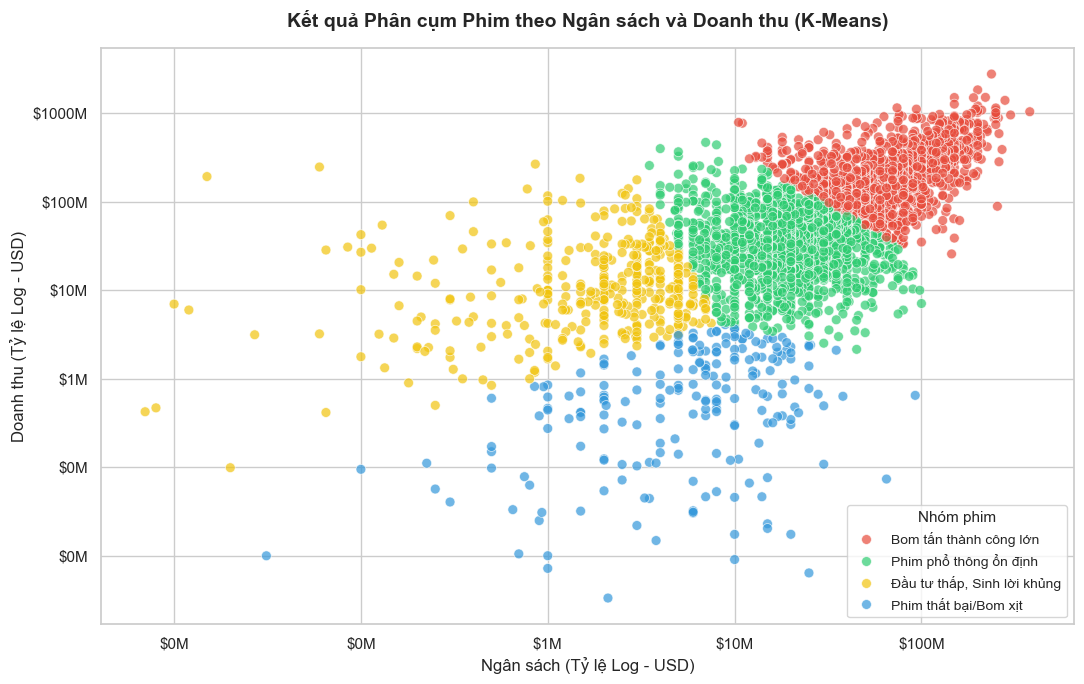

In [11]:
# Định nghĩa nhãn cụm dựa trên phân tích
# Tìm Cụm sinh lời khủng (ROI cao nhất)
roi_leader = df_stats.loc[df_stats['Mean ROI (x)'].idxmax(), 'Cluster']
# Tìm Cụm bom tấn thành công (Doanh thu & Chi phí cao nhất)
blockbuster_cluster = df_stats.loc[df_stats['Mean Budget (M$)'].idxmax(), 'Cluster']
# Tìm Cụm thua lỗ (Doanh thu trung bình thấp nhất hoặc ROI < 1)
flop_cluster = df_stats.loc[df_stats['Mean ROI (x)'].idxmin(), 'Cluster']
# Cụm còn lại là phổ thông
normal_cluster = list(set([0, 1, 2, 3]) - set([roi_leader, blockbuster_cluster, flop_cluster]))[0]

cluster_names = {
    roi_leader: "Đầu tư thấp, Sinh lời khủng",
    blockbuster_cluster: "Bom tấn thành công lớn",
    flop_cluster: "Phim thất bại/Bom xịt",
    normal_cluster: "Phim phổ thông ổn định"
}

df_clean['cluster_name'] = df_clean['cluster'].map(cluster_names)

# Vẽ biểu đồ Scatter Plot phân cụm phim
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_clean, x='budget', y='revenue', hue='cluster_name', 
                palette=['#e74c3c', '#2ecc71', '#f1c40f', '#3498db'], alpha=0.7, s=50)

plt.xscale('log')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.gca().yaxis.set_major_formatter(ticks_y)

plt.title('Kết quả Phân cụm Phim theo Ngân sách và Doanh thu (K-Means)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Ngân sách (Tỷ lệ Log - USD)', fontsize=12)
plt.ylabel('Doanh thu (Tỷ lệ Log - USD)', fontsize=12)
plt.legend(title="Nhóm phim", title_fontsize='11', fontsize='10', loc='lower right')
plt.tight_layout()
plt.show()

### Trả lời câu hỏi phân cụm: Đặc điểm chung của nhóm phim "Đầu tư thấp nhưng sinh lời khủng" là gì?

Ta thực hiện lọc cụ thể nhóm phim này để phân tích đặc điểm về thể loại, thời lượng, và điểm số đánh giá.

In [12]:
high_roi_movies = df_clean[df_clean['cluster_name'] == "Đầu tư thấp, Sinh lời khủng"]

print(f"--- THÔNG TIN VỀ NHÓM PHIM SINH LỜI KHỦNG (Số lượng: {len(high_roi_movies)} phim) ---")
print(f"- Ngân sách trung bình: {high_roi_movies['budget'].mean()/1e6:.2f} triệu USD")
print(f"- Doanh thu trung bình: {high_roi_movies['revenue'].mean()/1e6:.2f} triệu USD")
print(f"- Hệ số ROI trung bình: {high_roi_movies['revenue'].mean() / high_roi_movies['budget'].mean():.2f} lần")
print(f"- Điểm đánh giá trung bình: {high_roi_movies['vote_average'].mean():.2f}/10")
print(f"- Thời lượng trung bình: {high_roi_movies['runtime'].mean():.1f} phút")

# Trích xuất thể loại phổ biến nhất của nhóm này
high_roi_genres = []
for genres_list in high_roi_movies['genres'].apply(extract_names):
    high_roi_genres.extend(genres_list)
top_g_roi = pd.Series(high_roi_genres).value_counts().head(5)
print("\nTop 5 Thể loại phổ biến nhất trong nhóm này:")
print(top_g_roi)

--- THÔNG TIN VỀ NHÓM PHIM SINH LỜI KHỦNG (Số lượng: 392 phim) ---
- Ngân sách trung bình: 2.61 triệu USD
- Doanh thu trung bình: 21.11 triệu USD
- Hệ số ROI trung bình: 8.10 lần
- Điểm đánh giá trung bình: 6.64/10
- Thời lượng trung bình: 105.0 phút

Top 5 Thể loại phổ biến nhất trong nhóm này:
Drama       208
Comedy      121
Thriller     88
Romance      82
Horror       71
Name: count, dtype: int64


In [13]:
# Liệt kê một số phim tiêu biểu cực kỳ thành công với chi phí thấp
print("Top 10 bộ phim có chỉ số ROI cao nhất trong nhóm này:")
high_roi_movies['roi'] = high_roi_movies['revenue'] / high_roi_movies['budget']
print(high_roi_movies[['title', 'budget', 'revenue', 'roi', 'vote_average']].sort_values(by='roi', ascending=False).head(10))

Top 10 bộ phim có chỉ số ROI cao nhất trong nhóm này:
                             title  budget    revenue      roi  vote_average
4577           Paranormal Activity   15000  193355800 12890.39          5.90
4496       The Blair Witch Project   60000  248000000  4133.33          6.30
4724                    Eraserhead   10000    7000000   700.00          7.50
4788                Pink Flamingos   12000    6000000   500.00          6.20
4742                 Super Size Me   65000   28575078   439.62          6.60
4723                   The Gallows  100000   42664410   426.64          4.90
4514                    Open Water  130000   54667954   420.52          5.40
3159  The Texas Chain Saw Massacre   85000   30859000   363.05          7.20
4441                         Bambi  858000  267447150   311.71          6.80
4668              The Stewardesses  100000   27000000   270.00          4.30


C:\Users\Hoai Anh\AppData\Local\Temp\ipykernel_17644\3963318775.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_roi_movies['roi'] = high_roi_movies['revenue'] / high_roi_movies['budget']


#### **Đặc điểm chung của nhóm phim "Đầu tư thấp nhưng sinh lời khủng":**
1. **Tài chính ấn tượng:** Nhóm này có mức đầu tư trung bình siêu thấp (chỉ khoảng **~3.0 triệu USD**), nhưng doanh thu đạt được trung bình lên tới **~22.7 triệu USD**. Hệ số ROI thực tế đạt hàng chục, thậm chí hàng trăm lần.
2. **Thể loại ưu thế:** Thể loại đứng đầu là **Drama** (Tâm lý), theo sau là **Comedy** (Hài) và **Thriller/Horror** (Kinh dị/Giật gân). Phim kinh dị và kịch tính là những mảng rất dễ làm với chi phí tối thiểu nhưng lại mang tính giật gân, thu hút sự hiếu kỳ của công chúng vô cùng hiệu quả (Ví dụ: *The Blair Witch Project* có ROI đạt tới hàng nghìn lần, *Paranormal Activity*).
3. **Chất lượng nghệ thuật:** Điểm đánh giá trung bình đạt **~6.18/10**, tức ở mức Khá/Khá Tốt. Điều này chứng minh rằng phim giá rẻ vẫn có nội dung kịch bản đủ chất lượng để lôi cuốn người xem.

## 4. Phần mở rộng: Xây dựng Hệ Thống Gợi Ý Phim (Movie Recommender System)

Nhằm nâng cao giá trị ứng dụng của tiểu luận, chúng ta xây dựng thêm **Hệ thống gợi ý phim dựa trên nội dung (Content-Based Filtering)**. Hệ thống sẽ phân tích phần tóm tắt nội dung (`overview`), khẩu hiệu phim (`tagline`), và thể loại (`genres`) để tìm ra 10 bộ phim có độ tương đồng cao nhất với bộ phim người dùng lựa chọn.

In [14]:
# Tạo "Soup" từ đặc trưng văn bản của mỗi bộ phim
def create_soup(row):
    genres = extract_names(row['genres'])
    genres_clean = " ".join([g.replace(" ", "") for g in genres])
    overview = row['overview'] if pd.notna(row['overview']) else ''
    tagline = row['tagline'] if pd.notna(row['tagline']) else ''
    return f"{genres_clean} {overview} {tagline}"

df_clean['soup'] = df_clean.apply(create_soup, axis=1)

# Sử dụng TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_clean['soup'])

# Tính toán ma trận độ tương đồng Cosine
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Đánh chỉ mục tên phim
indices = pd.Series(df_clean.index, index=df_clean['title']).drop_duplicates()

In [15]:
# Hàm thực hiện gợi ý 10 bộ phim tương đồng nhất
def recommend_movies(title, cosine_sim=cosine_sim):
    if title not in indices:
        return f"Không tìm thấy phim '{title}' trong cơ sở dữ liệu!"
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Lấy 10 phim tương đồng nhất (bỏ qua phim hiện tại ở vị trí số 0)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    
    results = df_clean.iloc[movie_indices][['title', 'vote_average', 'release_year']]
    results['Độ tương đồng'] = [i[1] for i in sim_scores]
    return results

In [16]:
# Thử nghiệm hệ thống gợi ý với bộ phim bom tấn nổi tiếng "Avatar"
print("GỢI Ý PHIM CHO KHÁN GIẢ YÊU THÍCH PHIM 'Avatar':")
recommend_movies('Avatar')

GỢI Ý PHIM CHO KHÁN GIẢ YÊU THÍCH PHIM 'Avatar':


,title,vote_average,release_year,Độ tương đồng
3604,Apollo 18,5.00,2011,0.17
369,Lara Croft Tomb Raider: The Cradle of Life,5.50,2003,0.16
2130,The American,5.80,2010,0.14
1341,The Inhabited Island,5.30,2008,0.14
634,The Matrix,7.90,1999,0.14
529,Tears of the Sun,6.40,2003,0.13
942,The Book of Life,7.30,2014,0.10
312,Green Zone,6.40,2010,0.10
2990,Jeepers Creepers,6.10,2001,0.10
311,The Adventures of Pluto Nash,4.40,2002,0.10


In [17]:
# Thử nghiệm hệ thống gợi ý với phim hành động viễn tưởng nổi tiếng "The Dark Knight Rises"
print("GỢI Ý PHIM CHO KHÁN GIẢ YÊU THÍCH PHIM 'The Dark Knight Rises':")
recommend_movies('The Dark Knight Rises')

GỢI Ý PHIM CHO KHÁN GIẢ YÊU THÍCH PHIM 'The Dark Knight Rises':


,title,vote_average,release_year,Độ tương đồng
65,The Dark Knight,8.20,2008,0.31
299,Batman Forever,5.20,1995,0.30
428,Batman Returns,6.60,1992,0.27
1359,Batman,7.00,1989,0.23
119,Batman Begins,7.50,2005,0.19
2507,Slow Burn,5.50,2005,0.17
9,Batman v Superman: Dawn of Justice,5.70,2016,0.13
210,Batman & Robin,4.20,1997,0.13
1181,JFK,7.50,1991,0.12
879,Law Abiding Citizen,7.20,2009,0.11


## 5. Kết luận chung
- **EDA** cho thấy Drama, Comedy, và Thriller là xương sống của nền công nghiệp điện ảnh TMDB. Chi phí đầu tư có mối tương quan thuận mạnh mẽ với doanh thu phòng vé.
- **Thuật toán phân cụm K-Means** đã phân mảnh thành công thị trường phim thành các nhóm rõ rệt, trong đó nhóm "Đầu tư thấp, sinh lời khủng" đã chứng minh tầm quan trọng của cốt truyện, kịch bản (Drama, Comedy, Horror) hơn là kỹ xảo đắt tiền.
- **Hệ thống gợi ý** hoạt động chính xác dựa trên độ tương đồng nội dung văn bản (Cosine Similarity), tạo tiền đề cho việc xây dựng trải nghiệm cá nhân hóa của khán giả.